### B Vidakovic Quantum Framework for Wavelet Shrinkage
## Example 9

# Background in Quantum Soft Thresholding

## 1. Soft Thresholding Concept

In classical **wavelet soft thresholding**, a signal $d_i$ is shrunk according to a threshold $\lambda$:

$$
y_i = \text{sign}(d_i) \cdot \max(|d_i| - \lambda, 0)
$$

- Values $|d_i| \le \lambda$ are suppressed to $0$  
- Values $|d_i| > \lambda$ are reduced by $\lambda$  
- The sign of $d_i$ is preserved  

---

## 2. Encoding Data in a Quantum Ancilla

We implement a **quantum version of soft thresholding** using a **single ancilla qubit**:

1. Each classical normalized input value $d_i \in [-1,1]$  
2. Compute the **soft gain** (magnitude above threshold):

$$
g_i = \max(|d_i| - \lambda, 0)
$$

3. Map this soft gain to a **rotation angle** for the ancilla qubit:

$$
\theta_i = 2 \cdot \arcsin(\sqrt{g_i})
$$

- The factor of $2$ comes from the standard relation for a Ry rotation:

$$
R_y(\theta)|0\rangle = \cos(\theta/2)|0\rangle + \sin(\theta/2)|1\rangle
$$

- Then the **probability of measuring 1 on the ancilla** becomes:

$$
P(\text{flag}=1) = \sin^2(\theta_i / 2) = g_i = \max(|d_i| - \lambda, 0)
$$

✅ This ensures **exact soft thresholding** in magnitude.

---

## 3. Preserving the Sign

The ancilla only encodes the **magnitude above threshold**. To preserve the sign of the original signal, the final **thresholded signal** is reconstructed as:

$$
d_i^\text{thresh} = \text{sign}(d_i) \cdot P(\text{flag}=1) = \text{sign}(d_i) \cdot \max(|d_i| - \lambda, 0)
$$

- Positive values remain positive  
- Negative values remain negative  
- Values below the threshold are suppressed  

---

## 4. Quantum Circuit Implementation

For each normalized value $d_i$:

1. Prepare a single ancilla qubit in state $|0\rangle$  
2. Rotate it around the Y-axis by angle $\theta_i$:

```python
qc.ry(theta_i, 0)
qc.measure(0,0)


Normalized data: [ 0.263  0.158  1.     0.053  0.368 -1.     0.263  0.474]
Saved PNG: C:\Brani\MyJupyter\QThreshold\QwShrink\ex09anc_soft.png 124812 bytes
Saved PDF: C:\Brani\MyJupyter\QThreshold\QwShrink\ex09anc_soft.pdf 18592 bytes


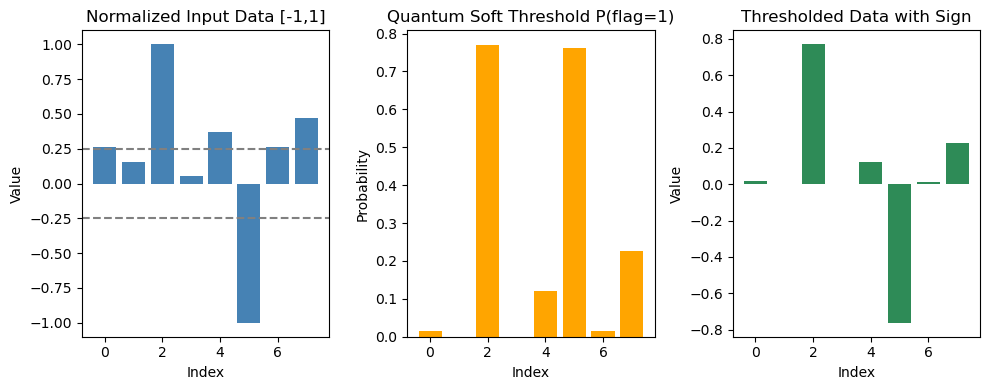

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# ------------------------------
# Data [-1,1]
# ------------------------------
dd = np.array([2, 1, 9, 0, 3, -10, 2, 4], dtype=float)
d = 2*(dd - dd.min())/(dd.max() - dd.min()) - 1  # normalized [-1,1]
print("Normalized data:", np.round(d,3))

threshold = 0.25  # threshold
backend = AerSimulator()

# ------------------------------
# Quantum soft threshold (ancilla)
# ------------------------------
def soft_threshold_flag_exact(value, threshold):
    qc = QuantumCircuit(1,1)
    # Compute probability = |value| - threshold
    prob = max(abs(value) - threshold, 0)
    # Map probability to rotation: sin^2(theta/2) = prob → theta = 2*arcsin(sqrt(prob))
    theta_flag = 2 * np.arcsin(np.sqrt(prob))
    qc.ry(theta_flag, 0)
    qc.measure(0,0)
    job = backend.run(transpile(qc, backend), shots=2048)
    res = job.result().get_counts()
    return res.get('1',0)/2048

# ------------------------------
# Compute probabilities
# ------------------------------
flags = np.array([soft_threshold_flag_exact(v, threshold) for v in d])

# Thresholded signal with sign
d_thresh = np.sign(d) * flags

# ------------------------------
# Plot results
# ------------------------------
fig = plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.bar(range(len(d)), d, color='steelblue')
plt.axhline(threshold, linestyle="--", color="gray")
plt.axhline(-threshold, linestyle="--", color="gray")
plt.title("Normalized Input Data [-1,1]")
plt.xlabel("Index"); plt.ylabel("Value")

plt.subplot(1,3,2)
plt.bar(range(len(d)), flags, color='orange')
plt.title("Quantum Soft Threshold P(flag=1)")
plt.xlabel("Index"); plt.ylabel("Probability")

plt.subplot(1,3,3)
plt.bar(range(len(d)), d_thresh, color='seagreen')
plt.title("Thresholded Data with Sign")
plt.xlabel("Index"); plt.ylabel("Value")

plt.tight_layout()
# -------------------------------------------------
# (3) Save BEFORE show(), with opaque bg
# -------------------------------------------------
png_name = "ex09anc_soft.png"
pdf_name = "ex09anc_soft.pdf"

fig.savefig(
    png_name,
    dpi=300,
    facecolor="white",
    edgecolor="white",
    transparent=False,
    bbox_inches="tight"
)

fig.savefig(
    pdf_name,
    dpi=300,
    facecolor="white",
    edgecolor="white",
    transparent=False,
    bbox_inches="tight"
)

# optional: confirm file sizes are nonzero so you don't upload a blank file
print("Saved PNG:", os.path.abspath(png_name),
      os.path.getsize(png_name), "bytes")
print("Saved PDF:", os.path.abspath(pdf_name),
      os.path.getsize(pdf_name), "bytes")



plt.show()

